# Yargıtay Dataset Audit

This notebook audits and visualizes a dataset where each record has (at least) the following schema:

```json
{
  "plaintiff_arguments": "Davacı vekili; müvekkilinin ...",
  "case_type_enum": "ALACAK_TAZMINAT",
  "outcome_enum": "GOREVSIZLIK",
  "chamber": "9. Hukuk Dairesi",
  "statute_ids": ["854-1", "6100-22"]
}
```

It produces **slide-ready** figures under `reports/figs_newformat/`.



In [ ]:
# === CONFIG ===
from pathlib import Path

DATA_PATH = Path("data/parsed_all.json")
FILE_FORMAT = "json"  

OUTPUT_DIR = Path("reports/figs_newformat")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bucket thresholds for head/mid/tail analysis 
HEAD_MIN = 30
MID_MIN  = 10

TOPN = 20        # top N categories/statutes for plots
RANDOM_SEED = 42

print("DATA_PATH:", DATA_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


DATA_PATH: /Users/eneskarabulut/Desktop/Desktop/ITU-YZV/YZV-25-26.1/YZV413-Graph Theory/graph-theory-term-project copy/data/parsed_all.json
OUTPUT_DIR: /Users/eneskarabulut/Desktop/Desktop/ITU-YZV/YZV-25-26.1/YZV413-Graph Theory/graph-theory-term-project copy/reports/figs_newformat


In [ ]:
import json
import pandas as pd
import numpy as np

def load_records(path: Path, file_format: str = "json"):
    if file_format.lower() == "jsonl":
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
        return rows
    else:
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        
        if isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
            return obj["data"]
        if isinstance(obj, list):
            return obj
        raise ValueError("Unsupported JSON structure. Expect list[...] or {data:[...]} or JSONL.")

records = load_records(DATA_PATH, FILE_FORMAT)
print("n_records:", len(records))

# Normalize into a flat dataframe with defaults
def norm_one(r: dict):
    return {
        "plaintiff_arguments": (r.get("plaintiff_arguments") or "").strip(),
        "case_type_enum": (r.get("case_type_enum") or "").strip() or None,
        "outcome_enum": (r.get("outcome_enum") or "").strip() or None,
        "chamber": (r.get("chamber") or "").strip() or None,
        "statute_ids": r.get("statute_ids") or [],
    }

df = pd.DataFrame([norm_one(r) for r in records])

# Basic cleanup
df["n_statutes"] = df["statute_ids"].apply(lambda xs: len(xs) if isinstance(xs, list) else 0)
df["pl_len"] = df["plaintiff_arguments"].astype(str).str.len()

df.head(3)


n_records: 2481


,plaintiff_arguments,case_type_enum,outcome_enum,chamber,statute_ids,year,n_statutes,pl_len
0,Davacı vekili; müvekkilinin iş sözleşmesinin f...,ISE_IADE,None,21. Hukuk Dairesi,[5521-1],None,1,129
1,Davacı vekili; müvekkilinin iş sözleşmesinin f...,ISE_IADE,None,21. Hukuk Dairesi,[5521-1],None,1,129
2,Davacı vekili; müvekkilinin **işçi** olarak ça...,ISE_IADE,None,21. Hukuk Dairesi,[5521-1],None,1,136


In [3]:
# === DATA QUALITY AUDIT ===
import pandas as pd
import numpy as np

audit = {
    "n_records": len(df),
    "missing_plaintiff_arguments": int((df["pl_len"] == 0).sum()),
    "missing_case_type_enum": int(df["case_type_enum"].isna().sum()),
    "missing_outcome_enum": int(df["outcome_enum"].isna().sum()),
    "missing_chamber": int(df["chamber"].isna().sum()),
    "missing_statute_ids": int((df["n_statutes"] == 0).sum()),
    "avg_pl_len": float(df["pl_len"].mean()),
    "median_pl_len": float(df["pl_len"].median()),
    "avg_n_statutes": float(df["n_statutes"].mean()),
    "median_n_statutes": float(df["n_statutes"].median()),
}

pd.DataFrame([audit])


,n_records,missing_plaintiff_arguments,missing_case_type_enum,missing_outcome_enum,missing_chamber,missing_statute_ids,avg_pl_len,median_pl_len,avg_n_statutes,median_n_statutes
0,2481,0,0,2481,0,221,188.036679,164.0,1.966949,2.0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # seaborn default theme
plt.rcParams["figure.dpi"] = 130

def savefig(name: str):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("saved:", path)


saved: reports/figs_newformat/01_outcome_distribution_top.png


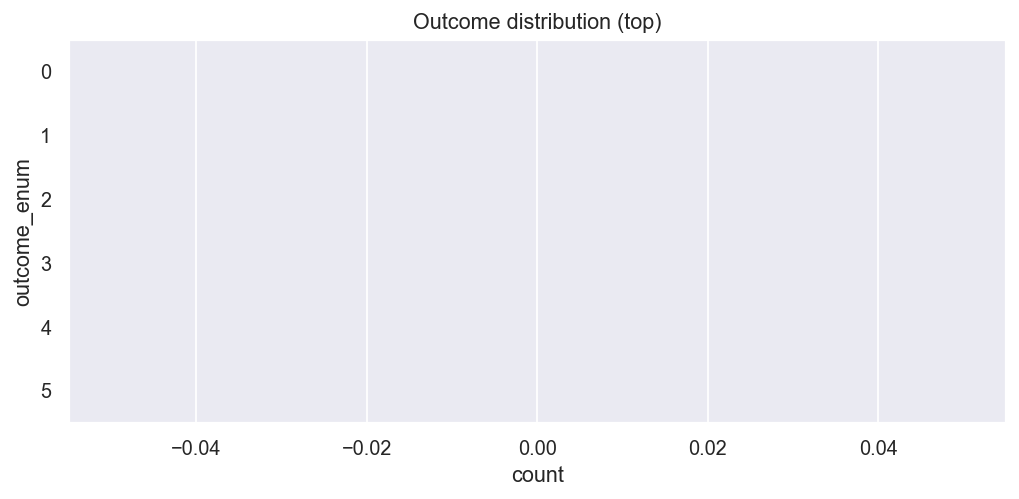

saved: reports/figs_newformat/02_chamber_distribution_top15.png


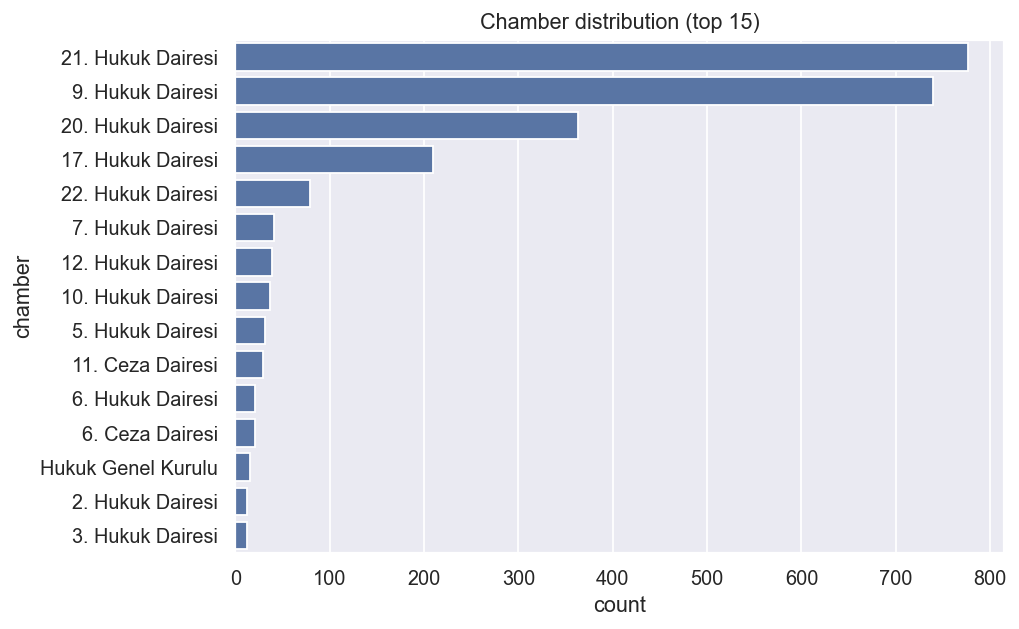

saved: reports/figs_newformat/03_case_type_distribution_top15.png


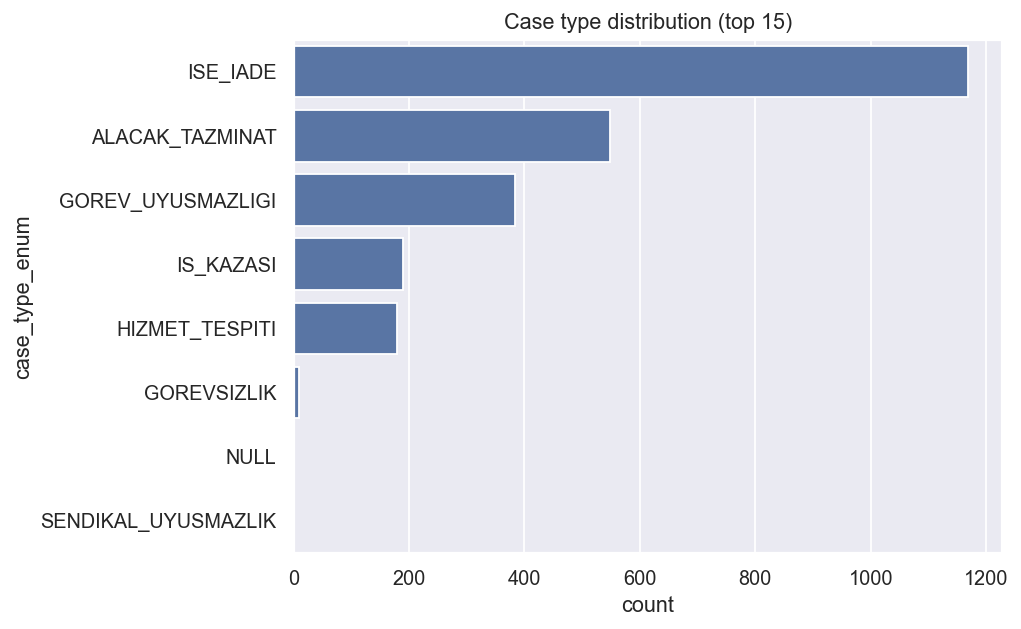

In [5]:
# === 1) Distributions: outcome, chamber, case_type ===

# Outcome distribution
plt.figure(figsize=(8,4))
order = df["outcome_enum"].value_counts().head(TOPN).index
sns.countplot(data=df, y="outcome_enum", order=order)
plt.title("Outcome distribution (top)")
plt.xlabel("count"); plt.ylabel("outcome_enum")
savefig("01_outcome_distribution_top.png")
plt.show()

# Chamber distribution
plt.figure(figsize=(8,5))
order = df["chamber"].value_counts().head(15).index
sns.countplot(data=df, y="chamber", order=order)
plt.title("Chamber distribution (top 15)")
plt.xlabel("count"); plt.ylabel("chamber")
savefig("02_chamber_distribution_top15.png")
plt.show()

# Case type distribution
plt.figure(figsize=(8,5))
order = df["case_type_enum"].value_counts().head(15).index
sns.countplot(data=df, y="case_type_enum", order=order)
plt.title("Case type distribution (top 15)")
plt.xlabel("count"); plt.ylabel("case_type_enum")
savefig("03_case_type_distribution_top15.png")
plt.show()


saved: reports/figs_newformat/04_plaintiff_len_hist.png


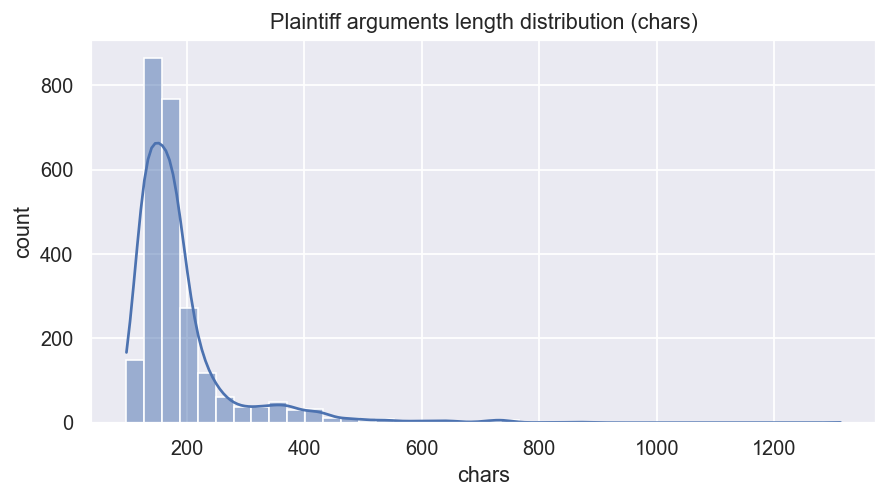

saved: reports/figs_newformat/05_n_statutes_hist.png


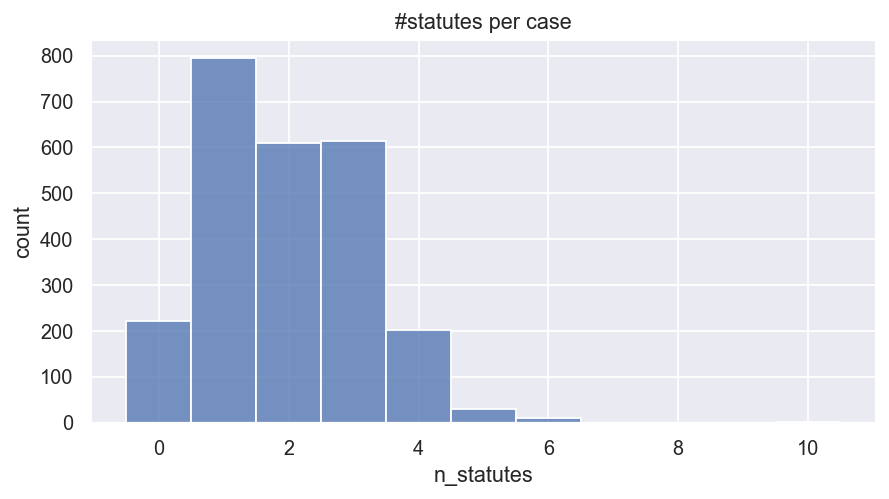

In [6]:
# === 2) Plaintiff-arguments length & statute counts ===

plt.figure(figsize=(7,4))
sns.histplot(df["pl_len"], bins=40, kde=True)
plt.title("Plaintiff arguments length distribution (chars)")
plt.xlabel("chars"); plt.ylabel("count")
savefig("04_plaintiff_len_hist.png")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["n_statutes"], bins=30, discrete=True)
plt.title("#statutes per case")
plt.xlabel("n_statutes"); plt.ylabel("count")
savefig("05_n_statutes_hist.png")
plt.show()


In [7]:
# === 3) Statute frequency analysis (global) ===
from collections import Counter

all_statutes = []
for xs in df["statute_ids"]:
    if isinstance(xs, list):
        all_statutes.extend([str(s) for s in xs if s])

freq = Counter(all_statutes)
freq_df = pd.DataFrame(freq.items(), columns=["statute_id", "count"]).sort_values("count", ascending=False)

print("unique statutes:", len(freq_df))
freq_df.head(10)


unique statutes: 298


,statute_id,count
0,5521-1,979
5,4857-18,461
6,4857-19,456
7,4857-20,456
2,6100-22,359
1,4857-25,281
9,6100-21,244
16,4857-21/3,164
8,5521-5,150
17,4857-1,112


saved: reports/figs_newformat/06_top20_statutes.png


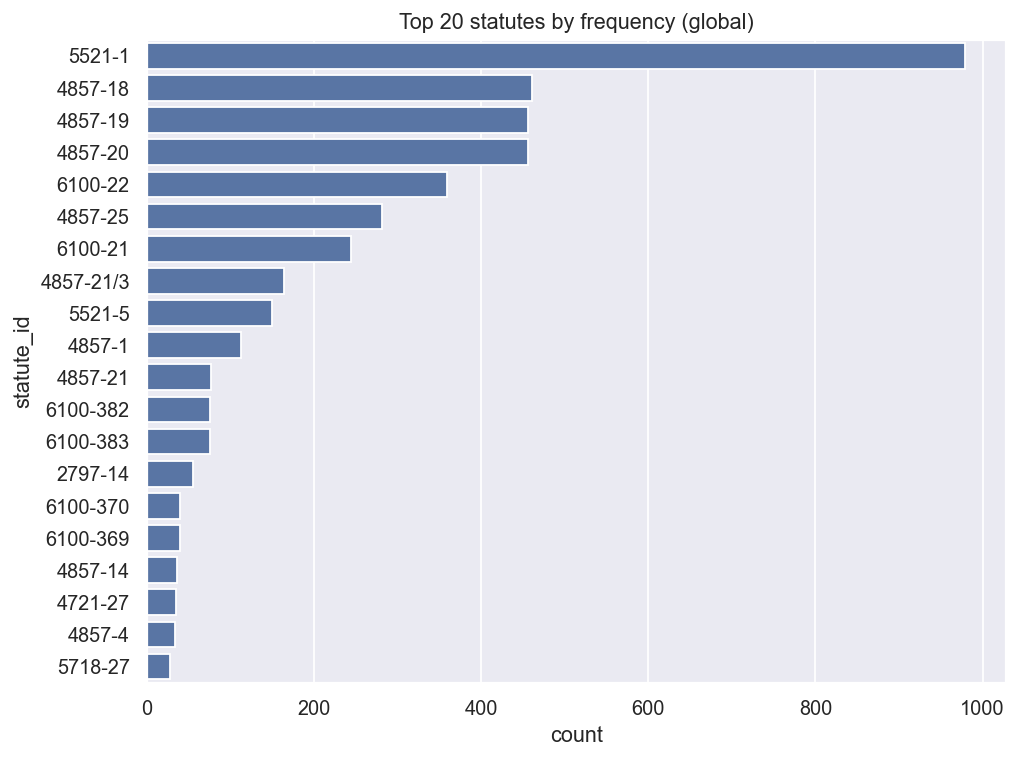

saved: reports/figs_newformat/07_statute_freq_loglog.png


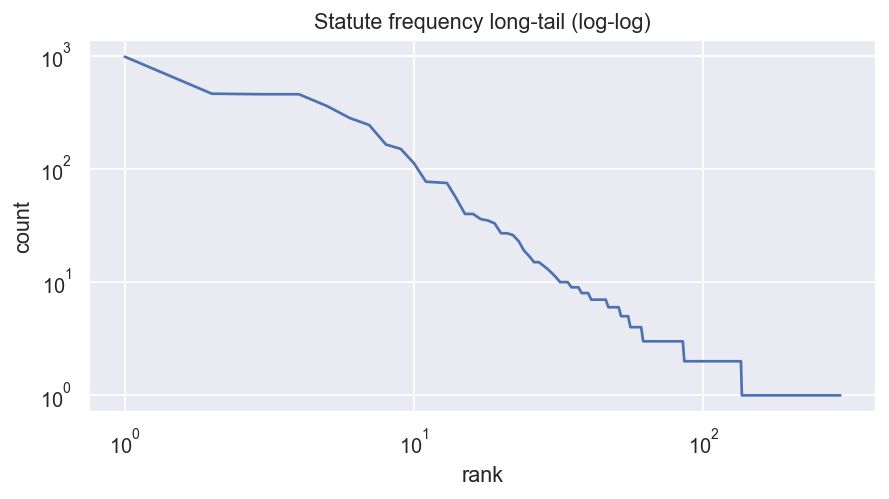

In [8]:
# Top statutes bar chart
plt.figure(figsize=(8,6))
top = freq_df.head(20).copy()
sns.barplot(data=top, x="count", y="statute_id")
plt.title("Top 20 statutes by frequency (global)")
plt.xlabel("count"); plt.ylabel("statute_id")
savefig("06_top20_statutes.png")
plt.show()

# Long tail view (log-log)
plt.figure(figsize=(7,4))
counts_sorted = np.sort(freq_df["count"].values)[::-1]
ranks = np.arange(1, len(counts_sorted)+1)
plt.loglog(ranks, counts_sorted)
plt.title("Statute frequency long-tail (log-log)")
plt.xlabel("rank"); plt.ylabel("count")
savefig("07_statute_freq_loglog.png")
plt.show()


In [9]:
# === 4) Head / Mid / Tail buckets (based on global frequency) ===

def bucket_of(count: int, head_min: int, mid_min: int):
    if count >= head_min:
        return "head"
    if count >= mid_min:
        return "mid"
    return "tail"

freq_df["bucket"] = freq_df["count"].apply(lambda c: bucket_of(int(c), HEAD_MIN, MID_MIN))

bucket_counts = freq_df["bucket"].value_counts().reindex(["head","mid","tail"]).fillna(0).astype(int)
bucket_counts


bucket
head     19
mid      15
tail    264
Name: count, dtype: int64

saved: reports/figs_newformat/08_bucket_unique_statutes.png


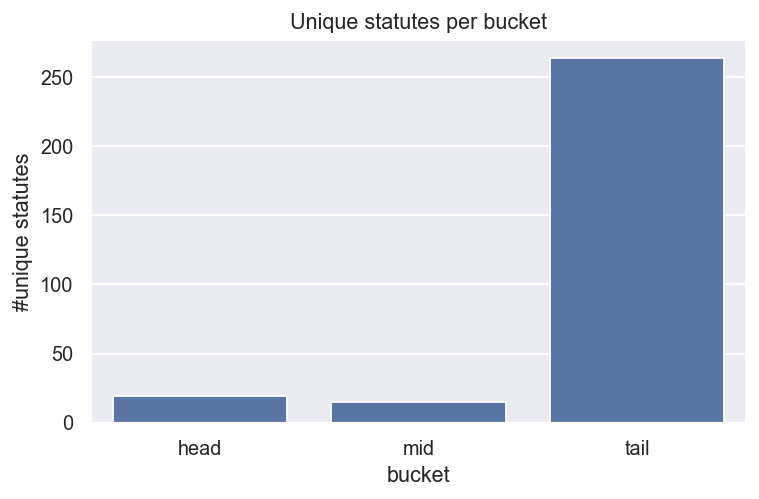

,head,mid,tail,unseen,total
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,2.0


In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x=bucket_counts.index, y=bucket_counts.values)
plt.title("Unique statutes per bucket")
plt.xlabel("bucket"); plt.ylabel("#unique statutes")
savefig("08_bucket_unique_statutes.png")
plt.show()

# Case-level bucket composition: for each case, what fraction of its statutes are head/mid/tail?
statute_to_bucket = dict(zip(freq_df["statute_id"], freq_df["bucket"]))

def case_bucket_stats(xs):
    xs = xs if isinstance(xs, list) else []
    buckets = [statute_to_bucket.get(str(s), "unseen") for s in xs]
    total = len(buckets)
    out = {b: 0 for b in ["head","mid","tail","unseen"]}
    if total == 0:
        return pd.Series({**out, "total": 0})
    for b in buckets:
        out[b] += 1
    out = {k: v/total for k, v in out.items()}
    out["total"] = total
    return pd.Series(out)

case_bucket = df["statute_ids"].apply(case_bucket_stats)
case_bucket.head()


saved: reports/figs_newformat/09_case_fraction_head_hist.png


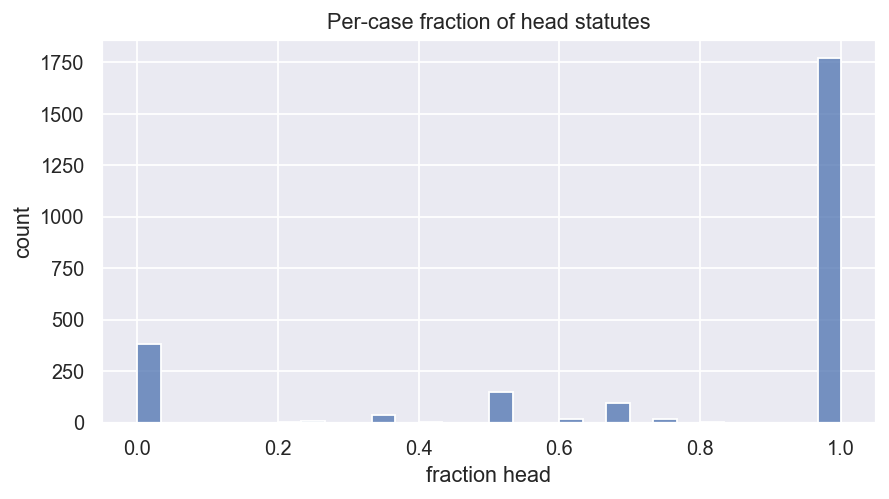

saved: reports/figs_newformat/10_case_fraction_tail_hist.png


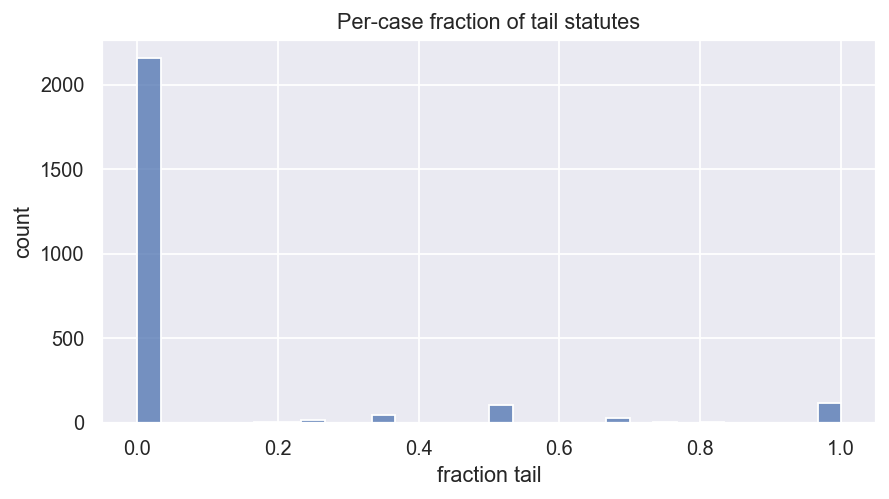

In [11]:
# Distribution of presence (does a case contain >=1 statute from bucket?)
presence = {
    "head": int((case_bucket["head"] > 0).sum()),
    "mid": int((case_bucket["mid"] > 0).sum()),
    "tail": int((case_bucket["tail"] > 0).sum()),
    "unseen": int((case_bucket["unseen"] > 0).sum()),
}
pd.DataFrame([presence])

plt.figure(figsize=(7,4))
sns.histplot(case_bucket["head"], bins=30)
plt.title("Per-case fraction of head statutes")
plt.xlabel("fraction head"); plt.ylabel("count")
savefig("09_case_fraction_head_hist.png")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(case_bucket["tail"], bins=30)
plt.title("Per-case fraction of tail statutes")
plt.xlabel("fraction tail"); plt.ylabel("count")
savefig("10_case_fraction_tail_hist.png")
plt.show()


saved: reports/figs_newformat/11_statute_cooccurrence_heatmap_top15.png


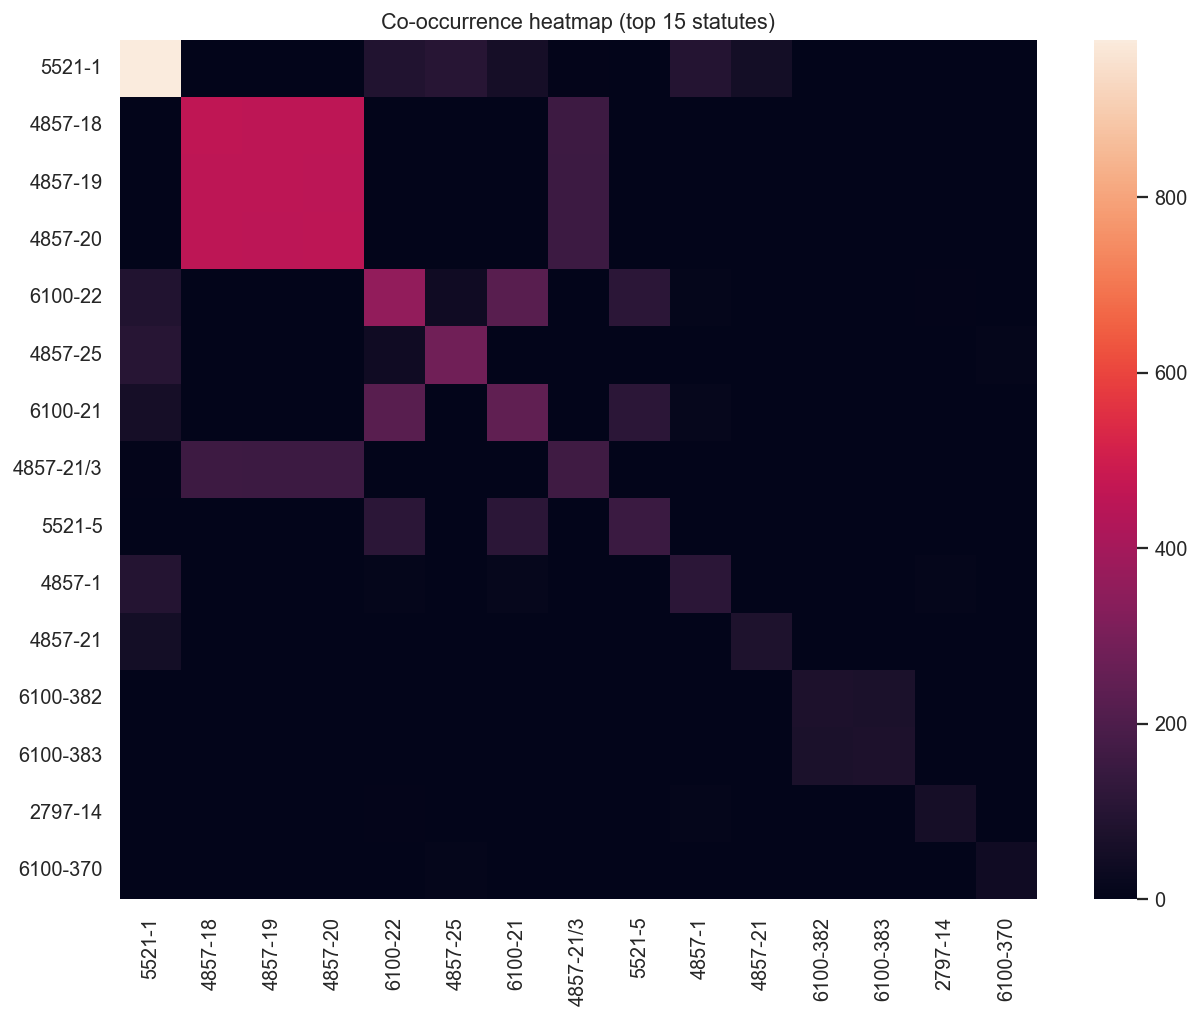

In [ ]:
# === 5) Statute co-occurrence among top statutes (heatmap) ===


top_statutes = freq_df.head(15)["statute_id"].tolist()

# Build binary matrix: rows=cases, cols=top statutes
bin_mat = np.zeros((len(df), len(top_statutes)), dtype=int)
stat_to_j = {s:j for j,s in enumerate(top_statutes)}

for i, xs in enumerate(df["statute_ids"]):
    xs = xs if isinstance(xs, list) else []
    for s in xs:
        s = str(s)
        if s in stat_to_j:
            bin_mat[i, stat_to_j[s]] = 1

# Co-occurrence = X^T X
co = bin_mat.T @ bin_mat
co_df = pd.DataFrame(co, index=top_statutes, columns=top_statutes)

plt.figure(figsize=(10,8))
sns.heatmap(co_df, annot=False)
plt.title("Co-occurrence heatmap (top 15 statutes)")
savefig("11_statute_cooccurrence_heatmap_top15.png")
plt.show()
